In [25]:
import pandas as pd 
import numpy as np 
from sklearn import linear_model
import matplotlib.pyplot as plt

In [26]:
df=pd.read_csv("C:\\Users\\preet\\DS_AI\\src\\day23\\homeprices.csv")
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


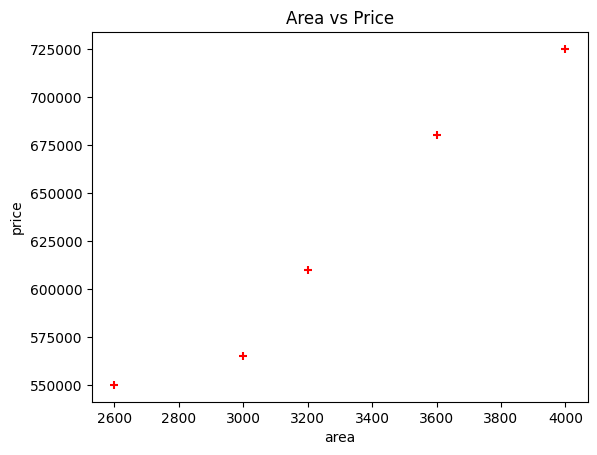

In [27]:
plt.title("Area vs Price")
plt.xlabel("area")
plt.ylabel("price")
plt.scatter(df.area,df.price,color="red",marker='+')
plt.show()


In [30]:
area=df.drop('price',axis=1)
area

,area
0,2600
1,3000
2,3200
3,3600
4,4000


In [31]:
price=df.price
price

0    550000
1    565000
2    610000
3    680000
4    725000
Name: price, dtype: int64

In [32]:
#equation for linear regression y=mx+c

reg=linear_model.LinearRegression()
reg.fit(area,price)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
reg.coef_


array([135.78767123])

In [34]:
reg.intercept_

np.float64(180616.43835616432)

In [37]:
#to predict the new area

new_data=pd.DataFrame([[3500]],columns=['area'])
prediction=reg.predict(new_data)
prediction=np.round(prediction,2)
prediction

array([655873.29])

In [38]:
#manual calulation
135.78767123 * 3500 * 180616.43835616432

85839199425.8414

In [39]:
p=reg.predict(df[['area']])
p=np.round(p,2)
p

array([533664.38, 587979.45, 615136.99, 669452.05, 723767.12])

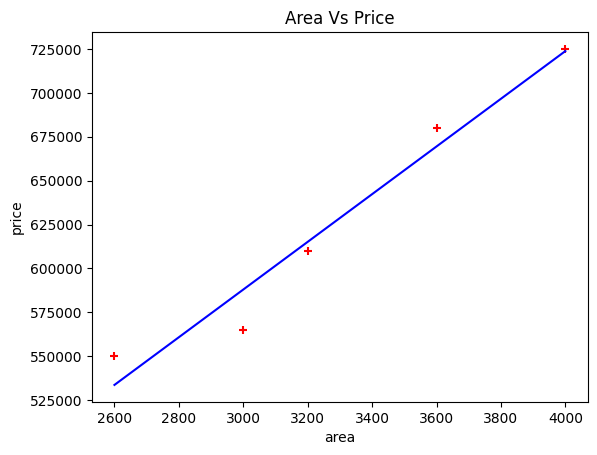

In [42]:
plt.title("Area Vs Price")
plt.xlabel("area")
plt.ylabel("price")
plt.scatter(df.area,df.price,color="red",marker='+')
plt.plot(df.area,reg.predict(df[['area']]),color='blue')
plt.show()

In [43]:
reg.score(df[['area']],df.price)

0.9584301138199486

In [44]:
#prediction for area=6500 and 10000

new_data=pd.DataFrame([[6500]],columns=['area'])
prediction=reg.predict(new_data)
prediction=np.round(prediction,2)
prediction

array([1063236.3])

In [45]:
#import and predict from areas,csv

areas=pd.read_csv("areas.csv")
areas

,area
0,1000
1,1500
2,2300
3,3540
4,4120
5,4560
6,5490
7,3460
8,4750
9,2300


In [46]:
pred=reg.predict(areas)
pred=np.round(pred,2)
pred

array([ 316404.11,  384297.95,  492928.08,  661304.79,  740061.64,
        799808.22,  926090.75,  650441.78,  825607.88,  492928.08,
       1402705.48, 1348390.41, 1144708.9 ])

In [47]:
areas['predicted_price']=pred
areas

,area,predicted_price
0,1000,316404.11
1,1500,384297.95
2,2300,492928.08
3,3540,661304.79
4,4120,740061.64
5,4560,799808.22
6,5490,926090.75
7,3460,650441.78
8,4750,825607.88
9,2300,492928.08


In [52]:
areas.to_csv("areas_no_index.csv",index=False)

In [53]:
reg.score(areas[['area']],areas.predicted_price)

0.9999999999999999